In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
from google.colab import files

uploaded = files.upload()

Saving adult_cleaned.csv to adult_cleaned.csv


[link text](https://)

In [5]:
df = pd.read_csv("adult_cleaned.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
X = df.drop("income", axis=1)

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Features:", X.shape)
print("Target:", y.shape)

Features: (32537, 14)
Target: (32537,)


In [7]:
categorical_columns = X.select_dtypes(include="object").columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (32537, 100)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 26029
Testing samples: 6508


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [10]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8122 - loss: 0.4002 - val_accuracy: 0.8386 - val_loss: 0.3478
Epoch 2/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8416 - loss: 0.3443 - val_accuracy: 0.8475 - val_loss: 0.3335
Epoch 3/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8475 - loss: 0.3292 - val_accuracy: 0.8459 - val_loss: 0.3304
Epoch 4/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8494 - loss: 0.3225 - val_accuracy: 0.8490 - val_loss: 0.3274
Epoch 5/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8509 - loss: 0.3191 - val_accuracy: 0.8471 - val_loss: 0.3278
Epoch 6/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8545 - loss: 0.3139 - val_accuracy: 0.8494 - val_loss: 0.3267
Epoch 7/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8550 - loss: 0.3112 - val_accuracy: 0.8454 - val_loss: 0.3321
Epoch 8/20
651/651 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8602 - loss: 0.3095 - val_accuracy: 0.

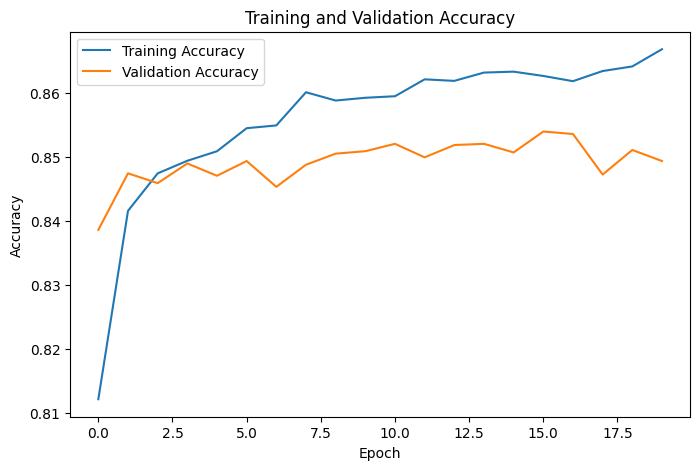

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

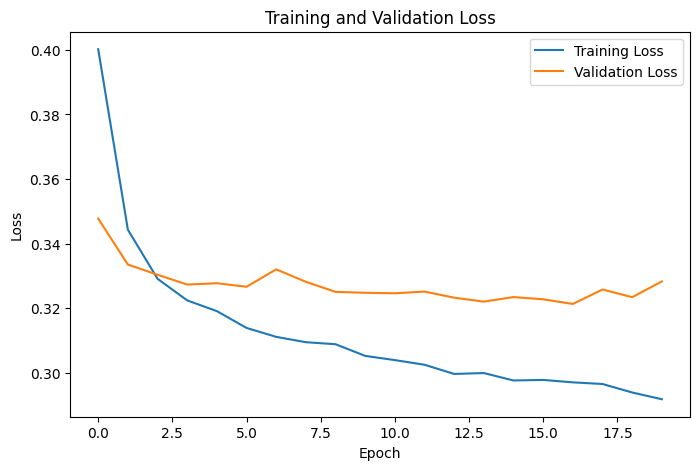

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
y_prob = model.predict(X_test_scaled)

y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions generated successfully!


In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8585
Precision: 0.7811
Recall   : 0.5733
F1 Score : 0.6613


In [17]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"]
    )
)

              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      4940
        >50K       0.78      0.57      0.66      1568

    accuracy                           0.86      6508
   macro avg       0.83      0.76      0.79      6508
weighted avg       0.85      0.86      0.85      6508



In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4688  252]
 [ 669  899]]


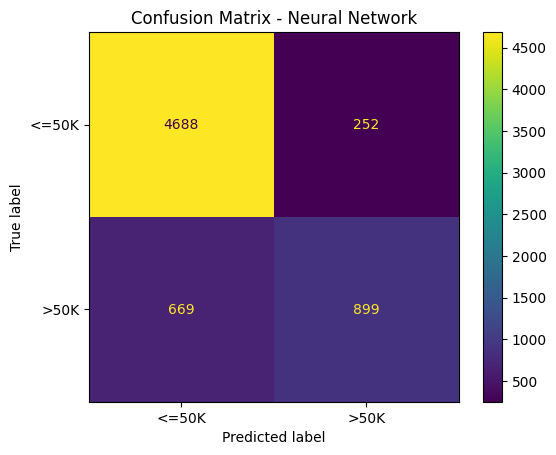

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot()

plt.title("Confusion Matrix - Neural Network")
plt.show()

In [20]:
print("FINAL DEEP LEARNING MODEL SUMMARY")
print("=" * 45)

print("Model: Feed-Forward Neural Network")
print("Input features:", X_train_scaled.shape[1])
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Epochs:", 20)
print("Batch size:", 32)

print("\nEvaluation Metrics")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nFinal Training Accuracy:",
      round(history.history["accuracy"][-1], 4))

print("Final Validation Accuracy:",
      round(history.history["val_accuracy"][-1], 4))

FINAL DEEP LEARNING MODEL SUMMARY
Model: Feed-Forward Neural Network
Input features: 100
Training samples: 26029
Testing samples: 6508
Epochs: 20
Batch size: 32

Evaluation Metrics
Accuracy : 0.8585
Precision: 0.7811
Recall   : 0.5733
F1 Score : 0.6613

Final Training Accuracy: 0.8669
Final Validation Accuracy: 0.8494
